## <center>Problem Sheet #4</center>

<img src="coding.gif" width="700">

<br>
### Red-black ordering for the Poisson equation 
<br>

<b>Problem 1.</b> Let us consider the following two-point BVP from Problem Sheet 1.

\begin{cases}
-u''(x)=1,\quad x\in(0,\pi/4)\\
u(0)=1\\
u(\pi/4)=2
\end{cases}

Let us apply the usual discreation with red-black (chess table) ordering! Plot the numerical and the true solutions in the same figure!

Reminder: $u(x)=-\frac{1}{2}x^2+\big(\frac{4}{\pi}+\frac{\pi}{8}\big)x+1$
<br>

norm_max =    1.9984e-15


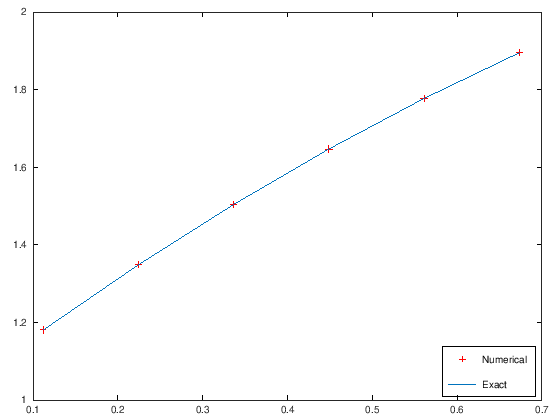

<br>
### Nine-point stencil for the two dimensional Poisson equation

<br>
<b>Problem 2.</b> Write a program which calculates the coefficient matrix corresponding the nine-point stencil discretization.
<br>

size_A_h =

   49   49



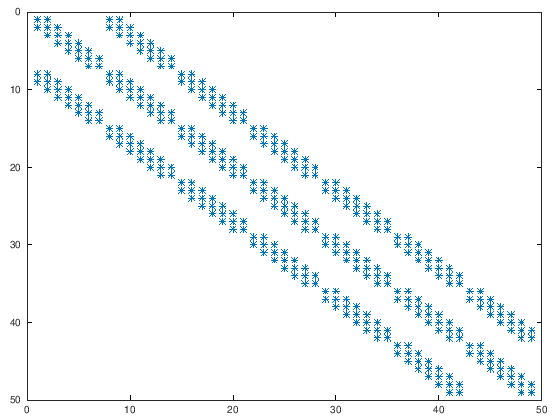

In [23]:
N=7;
%h=1/(N+1); % Let us comment it for a more visible structure!
e = ones(N,1);
S = spdiags([e 10*e e], [-1 0 1], N, N);
I = spdiags([-1/2*e e -1/2*e], [-1 0 1], N, N);
%A_h =1/(6*h^2)*(kron(I,S)+kron(S,I));
A_h =(kron(I,S)+kron(S,I));
coefficient_matrix=full(A_h);
spy(A_h) % Visualizing the nonzero entries
size_A_h=size(A_h)

<br>
<b>Problem 3.</b> Let us consider the Poisson equation on domain $\Omega=(-1,1)\times(-1,1)$ with homogeneous Dirichlet boundary condition, i.e.

\begin{cases}
-\Delta u= f\quad \Omega\textrm{-n}\\
u\big|_{\Gamma}=0, &
\end{cases}
where $f(x,y)\equiv 1$. The true solution is

$$u(x,y)=\frac{1-x^2}{2}-\frac{16}{\pi^3}\sum_{k\in\mathbb{N},\ k\ \mathrm{odd}} \frac{\sin\big(\frac{k\pi(1+x)}{2}\big)}{k^3\sinh(k\pi)}\Bigg(\sinh\bigg(\frac{k\pi(1+y)}{2}\bigg)+\sinh\bigg(\frac{k\pi(1-y)}{2}\bigg)\Bigg).$$

(a) Let us apply the five-point stencil if the step size is the same in both directions. Measure the global error at the origin if the (inner) grid points are $N=7,15,31,63,127,255$ and $511$! What can we experience?


global_error_at_origin =    1.41712496388169e-05
Elapsed time is 0.66679 seconds.


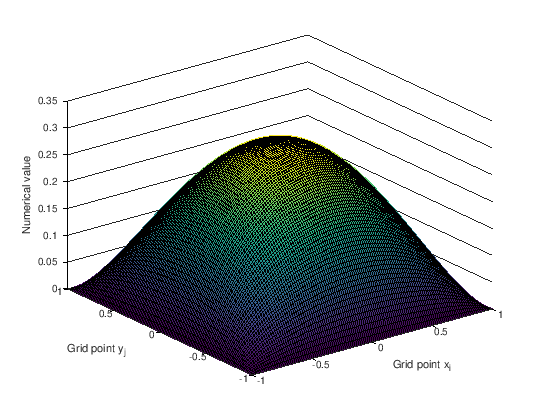

In [3]:
clear all
id=tic; %Measuring the time
N=127;%(Inner grid points)
h=2/(N+1);
% Creating the block matrix
e=ones(N,1);
B=spdiags([-e 4*e -e], [-1 0 1], N,N);
C=spdiags([-e -e],[-1 1],N,N);
I=speye(N);
A_h=1/(h^2)*(kron(I,B)+kron(C,I));
% Grid points; evaluation of the right hand side function f
f=ones(N^2,1);
% Numerical solution
yv=A_h\f;
ysquare=fliplr(reshape(flipud(yv),N,N)');%N^2 long vector
y=zeros(N+2);
y(2:N+1,2:N+1)=ysquare;
% Plot
[X,Y]=meshgrid(-1:h:1,-1:h:1);
surf(X,Y,y)
xlabel('Grid point x_i')
ylabel('Grid point y_j')
zlabel('Numerical value')

format long
NN=100;
xl=zeros(NN+1,1);%preallocation of the storage
for n=1:NN
xl(n+1) = sin((2*n-1)*pi/2)*2*sinh((2*n-1)*pi/2)/((2*n-1)^3*sinh((2*n-1)*pi)); 
%save every iteration result
end
xs=sum(xl);
exact=1/2-16*xs/(pi)^3;
numerical_at_origin=max(max(y));
format long
global_error_at_origin=abs(exact-numerical_at_origin)
toc(id)

<br>
(b) Let us apply the nine-point stencil if the step size is the same in both directions. Measure the global error at the origin if the (inner) grid points are N=7,15,31,63,127,255N=7,15,31,63,127,255 and 511511! What can we experience?

<br>

global_error_at_origin =    1.81322715776533e-05
Elapsed time is 0.223752 seconds.


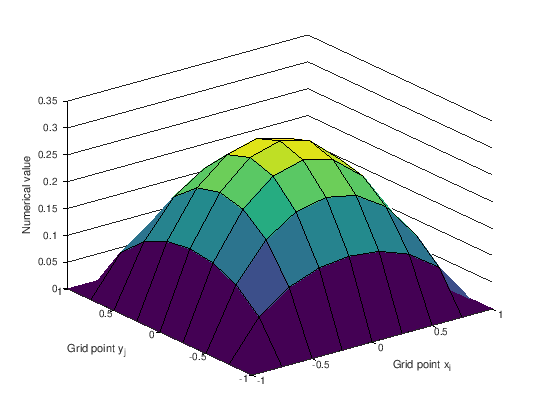

<br>

(c) Let us make a log-log type plot based on the previous result for $N=7,15,31,63,127,255$ and $511$! What can we see for the five-point and nine-point stencils?
<br>


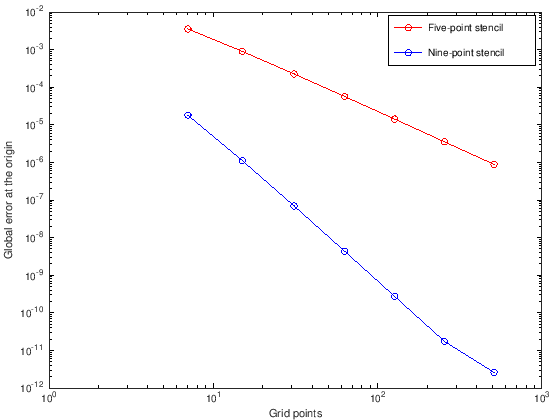

In [25]:
x=[3.55e-3 9.02e-4 2.26e-4 5.67e-5 1.42e-5 3.54e-6 8.86e-7];
y=[1.81e-5 1.12e-6 6.96e-8 4.35e-9 2.72e-10 1.74e-11 2.60e-12];
N=[7 15 31 63 127 255 511];
figure
loglog(N,x,'r-o',N,y,'b-o')
xlabel('Grid points')
ylabel('Global error at the origin')
legend('Five-point stencil','Nine-point stencil') 

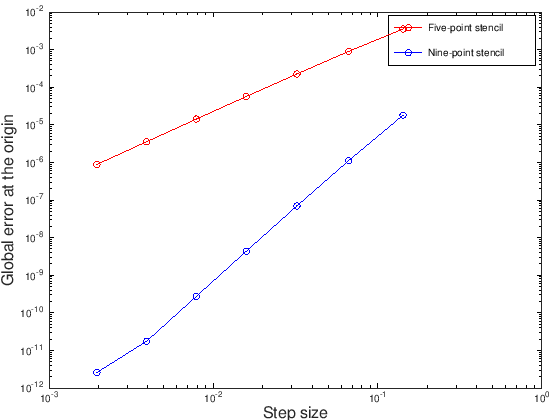

<br>
### Neumann boundary condition for the 2D case

<br>
<b>Problem 4.</b> Let us consider the following Poisson equation on the domain $\Omega=(0,1)\times(0,1)$

\begin{cases}
-\Delta u= f\quad \Omega\textrm{-n}\\
u\big|_{\Gamma}=g, &
\end{cases}

where $f(x,y)\equiv x+2y$. Tree sides of the square have a homogeneous Dirichlet boundary condition. The fourth one has the Neumann boundary condition $u_x(0,y)=y^2$. Let us apply the five-point stencil if the step size is the same in both directions. 

norm_maxmax =  0.137963647104926


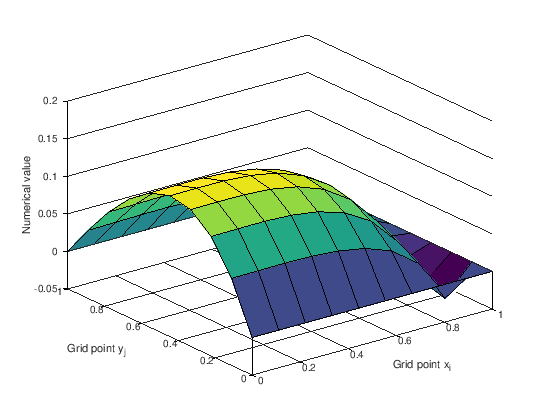